In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# df = pd.read_csv("../data/processed/customer_support_clean.csv")

In [4]:
df = pd.read_csv(
    "../data/processed/customer_support_clean.csv",
    parse_dates=[
        "issue_reported_at",
        "issue_responded",
        "survey_response_date"
    ]
)

/tmp/ipykernel_49610/1404393592.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


In [5]:
# convert to date
date_cols = [
    "issue_reported_at",
    "issue_responded",
    "survey_response_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [6]:
date_cols = [
    "issue_reported_at",
    "issue_responded",
    "survey_response_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S")

In [ ]:
df.shape

(85907, 21)

In [ ]:
df.head()

,unique_id,channel_name,category,sub-category,customer_remarks,order_id,order_date_time,issue_reported_at,issue_responded,survey_response_date,...,product_category,item_price,agent_name,supervisor,manager,tenure_bucket,agent_shift,csat_score,response_time_minutes,response_time_status
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,outcall,product_queries,life_insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,...,Unknown,NaN,richard_buchanan,mason_gupta,jennifer_nguyen,on_job_training,morning,5,34.0,Valid
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,outcall,product_queries,product_specific_information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,...,Unknown,NaN,vicki_collins,dylan_kim,michael_lee,>90,morning,5,2.0,Valid
2,200814dd-27c7-4149-ba2b-bd3af3092880,inbound,order_related,installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,...,Unknown,NaN,duane_norman,jackson_park,william_kim,on_job_training,evening,5,22.0,Valid
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,inbound,returns,reverse_pickup_enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,...,Unknown,NaN,patrick_flores,olivia_wang,john_smith,>90,evening,5,20.0,Valid
4,ba903143-1e54-406c-b969-46c52f92e5df,inbound,cancellation,not_needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,...,Unknown,NaN,christopher_sanchez,austin_johnson,michael_lee,0-30,morning,5,2.0,Valid


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   unique_id              85907 non-null  str           
 1   channel_name           85907 non-null  str           
 2   category               85907 non-null  str           
 3   sub-category           85907 non-null  str           
 4   customer_remarks       28742 non-null  str           
 5   order_id               67675 non-null  str           
 6   order_date_time        17214 non-null  str           
 7   issue_reported_at      85907 non-null  datetime64[us]
 8   issue_responded        85907 non-null  datetime64[us]
 9   survey_response_date   85907 non-null  datetime64[us]
 10  customer_city          85907 non-null  str           
 11  product_category       85907 non-null  str           
 12  item_price             17206 non-null  float64       
 13  agent_name  

In [ ]:
#CSAT Distribution
df["csat_score"].value_counts().sort_index()

csat_score
1    11230
2     1283
3     2558
4    11219
5    59617
Name: count, dtype: int64

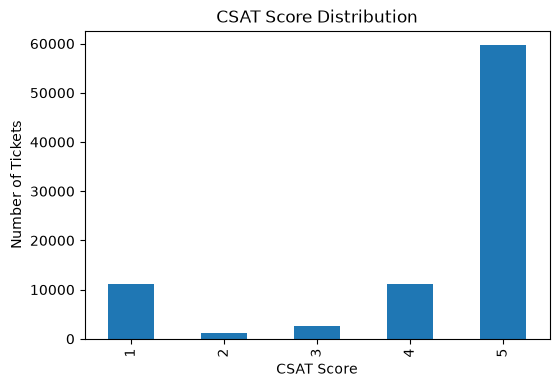

In [ ]:
plt.figure(figsize=(6,4))

df["csat_score"].value_counts().sort_index().plot(kind="bar")

plt.title("CSAT Score Distribution")
plt.xlabel("CSAT Score")
plt.ylabel("Number of Tickets")

plt.show()

In [17]:
# df["csat_score"].value_counts() 
df['csat_score'].value_counts(normalize=True) * 100



csat_score
5    69.397139
1    13.072276
4    13.059471
3     2.977639
2     1.493476
Name: proportion, dtype: float64

for the review ratings , rating 5 took 69% of the total rating counts revealing a pass mark on the average. However rating 1 and 4 followed it ( although distant) with 13% each, some considerarion should be shown towards the 1 rating.

In [20]:
# Channel Distribution
df["channel_name"].value_counts(normalize=True)*100

channel_name
inbound    79.320661
outcall    17.160418
email       3.518922
Name: proportion, dtype: float64

email is the lowest of the support tickets while the traditional inbound (walk in) still records the most tickets 

Inbound support is the primary customer contact channel, accounting for nearly four out of every five support interactions. Email represents only a small proportion of tickets, suggesting customers prefer real-time support channels.

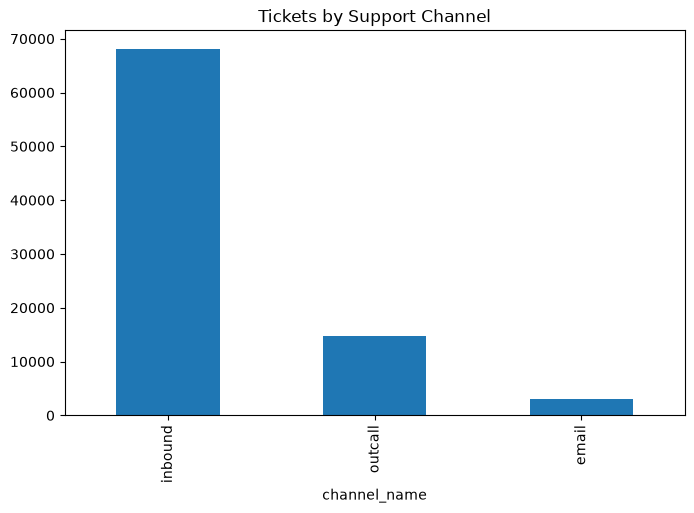

In [ ]:
plt.figure(figsize=(8,5))

df["channel_name"].value_counts().plot(kind="bar")

plt.title("Tickets by Support Channel")

plt.show()

In [7]:
# Top Categories

# df["category"].value_counts()
df["category"].value_counts(normalize=True)*100


category
returns               51.331091
order_related         27.023409
refund_related         5.296425
product_queries        4.297671
shopzilla_related      3.250026
payments_related       2.708743
feedback               2.670330
cancellation           2.574877
offers_&_cashback      0.558744
others                 0.115241
app/website            0.097780
onboarding_related     0.075663
Name: proportion, dtype: float64

returns have been so much, taking half of the whole support tickets. 
order related is the next on the highest ticket

Return-related issues account for over half of all customer support tickets, making returns the dominant operational challenge. Order-related enquiries are the second-largest category, indicating that these two areas should be prioritised for process improvement.

In [19]:
#Agent shifts
df["agent_shift"].value_counts(normalize=True)*100

agent_shift
morning      48.221914
evening      39.201695
afternoon     6.798049
split         4.246453
night         1.531889
Name: proportion, dtype: float64

morning took more than half meaning morning is business as usual perhaps because the traditional work pattern supports morning more, followed by evening perhaps when they are about to close.


Shift	% of Tickets
Morning	?
Evening	?
Afternoon	?
Night	?

<!-- Percentages tell a clearer story than raw counts. -->

In [ ]:
#Tenure Buckets
df["tenure_bucket"].value_counts()

tenure_bucket
>90                30660
on_job_training    25523
31-60              11665
0-30               11318
61-90               6741
Name: count, dtype: int64

on job training have done extremely well perhaps because they're seeking for permanent employment
also those above 90 days are the highest as they've more wxperince on the job
but worryingly those between 61-90 are the lowest, what could be the cause

Agents with more than 90 days of tenure and those in the On Job Training group handled the largest share of tickets. This may indicate higher staffing levels within these groups or greater workload allocation, but the dataset does not identify the underlying reason.

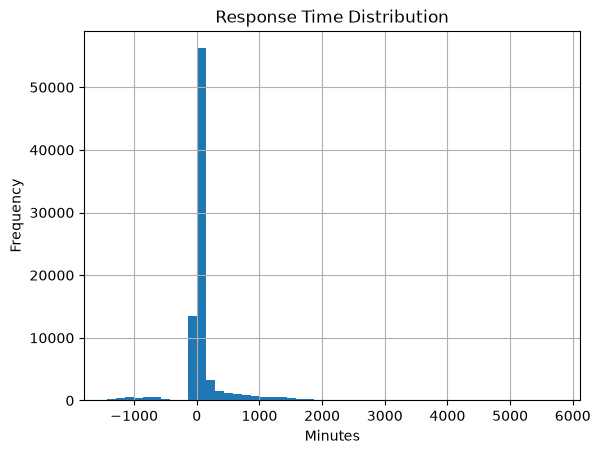

In [ ]:
#Response time analysis

df["response_time_minutes"].hist(bins=50)

plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.title("Response Time Distribution")

plt.show()

In [ ]:
df["response_time_minutes"].sort_values()

75692   -1437.0
74420   -1436.0
75053   -1435.0
75665   -1433.0
77299   -1428.0
          ...  
27587    5729.0
41735    5734.0
30734    5737.0
5597     5742.0
23525    5758.0
Name: response_time_minutes, Length: 85907, dtype: float64

majority are less than 2000
some bunch are in the negative side
also more centered on 0
there also seem to be some extreme values like 6000,5000,4000 minutes

The response-time distribution is highly right-skewed. Most tickets are resolved quickly, but a relatively small number of extreme response times substantially increase the overall average. A small proportion of negative response times were identified during data cleaning and flagged as invalid timestamps.

In [15]:
(len(df[df["response_time_minutes"] <0]) / len(df)) * 100

3.6411468215628533

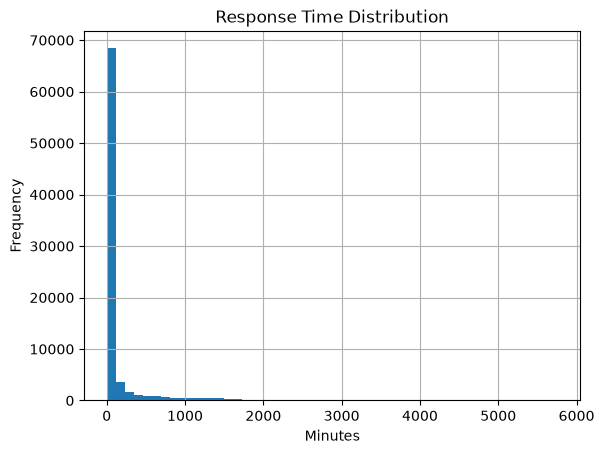

In [5]:
valid_df = df[df["response_time_status"] == "Valid"]

valid_df["response_time_minutes"].hist(bins=50)

plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.title("Response Time Distribution")

plt.show()

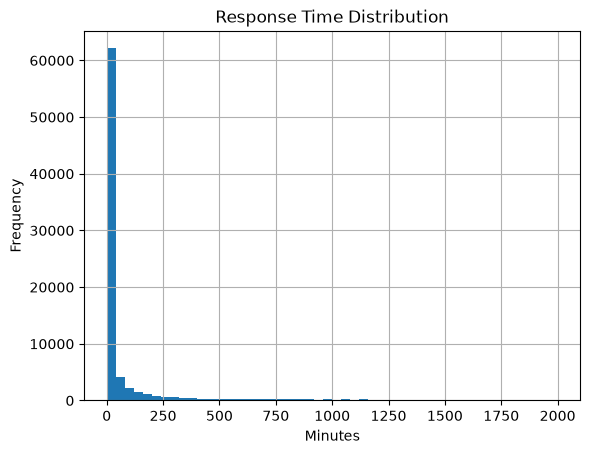

In [ ]:
# valid_df = df[df["response_time_status"] == "Valid"]
balance_df = valid_df[valid_df["response_time_minutes"] <= 2000]

balance_df["response_time_minutes"].hist(bins=50)

plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.title("Response Time Distribution")

plt.show()

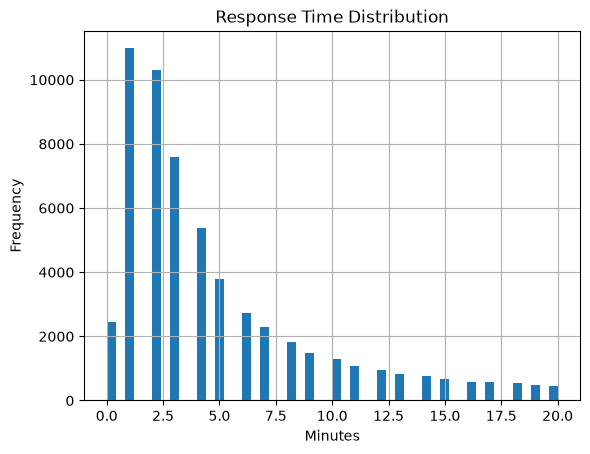

In [ ]:
balance_df = valid_df[valid_df["response_time_minutes"] <= 20]

balance_df["response_time_minutes"].hist(bins=50)

plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.title("Response Time Distribution")

plt.show()

Text(0, 0.5, 'Average CSAT Score')

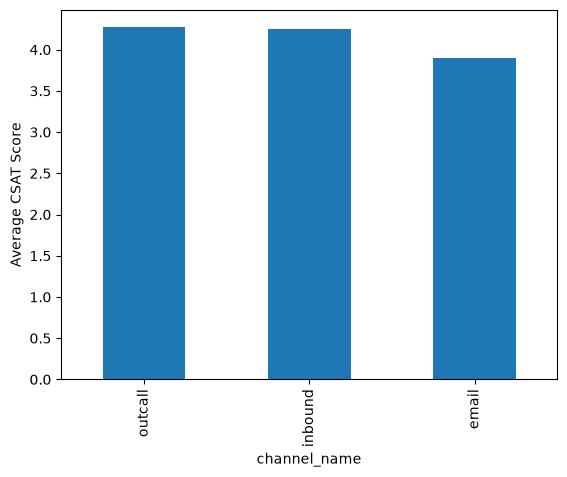

In [ ]:
#Bivariate


#Average CSAT by Channel

df.groupby("channel_name")["csat_score"].mean().sort_values(ascending=False).plot(kind="bar")
plt.ylabel("Average CSAT Score");

In [ ]:

df.groupby("channel_name")["csat_score"].mean().sort_values(ascending=False)

channel_name
outcall    4.269909
inbound    4.251372
email      3.899107
Name: csat_score, dtype: float64

outcall has the highest average rating over 4.0 
while email has the lowest despite having very few support tickets

Outcall support achieved the highest average customer satisfaction score (4.27), while email support recorded the lowest (3.90). Although email handles relatively few tickets, the lower satisfaction suggests an opportunity to review response quality or turnaround time for that channel.

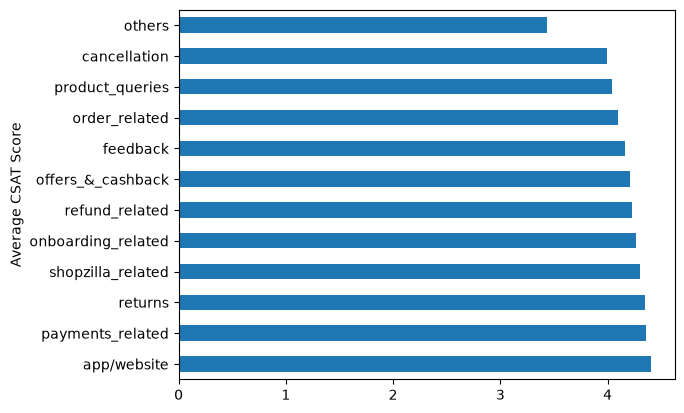

In [ ]:
# Average CSAT by Category
df.groupby("category")["csat_score"].mean().sort_values(ascending=False).plot(kind="barh")

plt.ylabel("Average CSAT Score");

In [ ]:
df.groupby("category")["csat_score"].mean().sort_values(ascending=False)

category
app/website           4.404762
payments_related      4.354534
returns               4.346350
shopzilla_related     4.306948
onboarding_related    4.261538
refund_related        4.226813
offers_&_cashback     4.210417
feedback              4.158675
order_related         4.096059
product_queries       4.039816
cancellation          3.990506
others                3.434343
Name: csat_score, dtype: float64

support tickets from the app/website has the highest average CSAT score 
while cancellation recorded the lowest after others
suprisingly, returns alsorecorded an high average CSAT score (>4)

App/Website enquiries achieved the highest average CSAT score (4.40), whereas 'Others' and Cancellation-related issues received the lowest satisfaction ratings. Cancellation requests may warrant further investigation to identify pain points in the customer journey.

In [6]:
df["dayofweek"] = df["issue_reported_at"].dt.day_name()

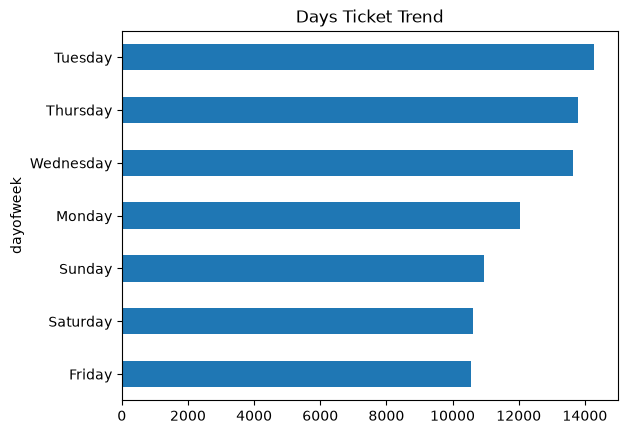

In [ ]:
day = df.groupby("dayofweek").size()

day.sort_values().plot(kind="barh")

plt.title("Days Ticket Trend")

plt.show()

In [67]:

day.sort_values()

dayofweek
Friday       10564
Saturday     10630
Sunday       10942
Monday       12053
Wednesday    13633
Thursday     13803
Tuesday      14282
dtype: int64

Tuesday has the highest issue reported at
the weekends  (Friday, Saturday, Sunday) recorded the lowest respectinely

Support demand peaks on Tuesdays and gradually declines toward the weekend. This pattern suggests that staffing levels should be aligned with higher weekday demand to maintain service quality.

In [ ]:
#Average response time by shift
valid_df.groupby("agent_shift")["response_time_minutes"].mean()

agent_shift
afternoon    204.899630
evening      174.667786
morning      171.176033
night        201.123447
split        188.418650
Name: response_time_minutes, dtype: float64

average response time by minutes recorded the highest in the aftertoon shift and we should not forget that they had a low support tickets, maybe they're usually occupied by other things during that period

The afternoon shift records the highest average response time despite handling fewer tickets than the morning shift. Further investigation is required to determine whether this is driven by staffing levels, ticket complexity, or operational processes.

In [ ]:
#Average response time by agent

valid_df.groupby("agent_name")["response_time_minutes"].mean().sort_values()

agent_name
joel_garcia             8.368421
jacob_moore            11.291667
virginia_diaz          14.897436
michael_perez          15.666667
mr._allen_fisher       16.080000
                         ...    
ryan_khan             550.291667
amy_bell              582.333333
virginia_mccormick    603.558824
elizabeth_rose        651.380952
christine_castro      681.928571
Name: response_time_minutes, Length: 1371, dtype: float64

                       item_price  csat_score  response_time_minutes
item_price               1.000000   -0.122741               0.003730
csat_score              -0.122741    1.000000              -0.149264
response_time_minutes    0.003730   -0.149264               1.000000


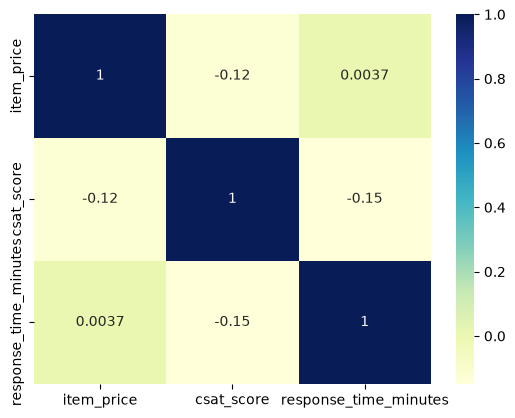

In [ ]:
cor_mtx = valid_df.corr(numeric_only=True)

# Print correlation matrix
print(cor_mtx)

# Plot correlation heatmap
sns.heatmap(cor_mtx, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show();

There is a weak negative relationship between response time and customer satisfaction (r = -0.149), suggesting that faster responses are generally associated with higher CSAT scores. However, the low magnitude indicates that improving response speed alone is unlikely to maximize customer satisfaction.

Item price does not appear to influence response time, suggesting that support requests are handled independently of product value.


Item Price vs CSAT (-0.123)

In [7]:
import numpy as np
from scipy import stats

In [ ]:
result = stats.spearmanr(df['csat_score'], df['response_time_minutes'])

In [37]:
print("--- Spearman Correlation Results ---")
print(f"Spearman Correlation (rho): {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.4f}")

--- Spearman Correlation Results ---
Spearman Correlation (rho): -0.1854
P-value: 0.0000


In [8]:
groups = [
    group_data["csat_score"].values
    for _, group_data in df.groupby("channel_name")
]

h_statistic, p_value = stats.kruskal(*groups)

print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value:.6f}")

H-statistic: 151.1141
P-value: 0.000000


In [11]:
groups = [
    group_data["csat_score"].values
    for _, group_data in df.groupby("product_category")
]

h_statistic, p_value = stats.kruskal(*groups)

print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value:.6f}")

H-statistic: 773.3052
P-value: 0.000000


In [13]:
import scikit_posthocs as sp


posthoc = sp.posthoc_dunn(
    df,
    val_col="csat_score",
    group_col="channel_name",
    p_adjust="bonferroni"
)

print(posthoc)

                email       inbound       outcall
email    1.000000e+00  1.383414e-32  2.490070e-32
inbound  1.383414e-32  1.000000e+00  2.612625e-01
outcall  2.490070e-32  2.612625e-01  1.000000e+00


The Kruskal–Wallis test told us at least one support channel differs in CSAT. While the Dunn's Test (with Bonferroni correction) post-hoc test tells us which ones.

A Kruskal–Wallis H test indicated a statistically significant difference in customer satisfaction across support channels (H = 151.11, p < 0.001). Dunn's post-hoc test with Bonferroni correction revealed that Email support had significantly lower CSAT scores than both Inbound and Outcall support (adjusted p < 0.001 for both comparisons). No significant difference was observed between Inbound and Outcall support (adjusted p = 0.261).

for the review ratings , rating 5 took 69% of the total rating counts revealing a pass mark on the average. However rating 1 and 4 followed it ( although distant) with 13% each, some considerarion should be shown towards the 1 rating.

email is the lowest of the support tickets while the traditional inbound (walk in) still records the most tickets 
Inbound support is the primary customer contact channel, accounting for nearly four out of every five support interactions. Email represents only a small proportion of tickets, suggesting customers prefer real-time support channels.

returns have been so much, taking half of the whole support tickets. 
order related is the next on the highest ticket

Return-related issues account for over half of all customer support tickets, making returns the dominant operational challenge. Order-related enquiries are the second-largest category, indicating that these two areas should be prioritised for process improvement.

morning took almost half (49.2%) meaning morning is business as usual perhaps because the traditional work pattern supports morning more, followed by evening perhaps when they are about to close.

on job training have done extremely well perhaps because they're seeking for permanent employment
also those above 90 days are the highest as they've more wxperince on the job
but worryingly those between 61-90 are the lowest, what could be the cause

Agents with more than 90 days of tenure and those in the On Job Training group handled the largest share of tickets. This may indicate higher staffing levels within these groups or greater workload allocation, but the dataset does not identify the underlying reason.

majority are less than 2000
some bunch are in the negative side
also more centered on 0
there also seem to be some extreme values like 6000,5000,4000 minutes

The response-time distribution is highly right-skewed. Most tickets are resolved quickly, but a relatively small number of extreme response times substantially increase the overall average. A small proportion of negative response times were identified during data cleaning and flagged as invalid timestamps.

Outcall support achieved the highest average customer satisfaction score (4.27), while email support recorded the lowest (3.90). Although email handles relatively few tickets, the lower satisfaction suggests an opportunity to review response quality or turnaround time for that channel.

support tickets from the app/website has the highest average CSAT score 
while cancellation recorded the lowest after others
suprisingly, returns alsorecorded an high average CSAT score (>4)

App/Website enquiries achieved the highest average CSAT score (4.40), whereas 'Others' and Cancellation-related issues received the lowest satisfaction ratings. Cancellation requests may warrant further investigation to identify pain points in the customer journey.

Support demand peaks on Tuesdays and gradually declines toward the weekend. This pattern suggests that staffing levels should be aligned with higher weekday demand to maintain service quality.

There is a weak negative relationship between response time and customer satisfaction (r = -0.149), suggesting that faster responses are generally associated with higher CSAT scores. However, the low magnitude indicates that improving response speed alone is unlikely to maximize customer satisfaction.

Item price does not appear to influence response time, suggesting that support requests are handled independently of product value.


Item Price vs CSAT (-0.123)

A Kruskal–Wallis H test indicated a statistically significant difference in customer satisfaction across support channels (H = 151.11, p < 0.001). Dunn's post-hoc test with Bonferroni correction revealed that Email support had significantly lower CSAT scores than both Inbound and Outcall support (adjusted p < 0.001 for both comparisons). No significant difference was observed between Inbound and Outcall support (adjusted p = 0.261).

## Key Findings

---

### 1. Customer Satisfaction (CSAT) Distribution

Customer satisfaction ratings were overwhelmingly positive, with **Rating 5 accounting for approximately 69% of all responses**. This indicates that the majority of customers were highly satisfied with the support they received. However, **Ratings 1 and 4 each contributed around 13% of the responses**, suggesting that while overall performance is strong, a notable proportion of customers still report poor experiences. Investigating the drivers of these low ratings could provide opportunities to further improve service quality.

---

### 2. Support Channels

Inbound support dominates customer interactions, accounting for **almost four out of every five (80%) support tickets**. Outcall services represent a much smaller proportion, while Email contributes only a small fraction (3%) of total tickets. This suggests that customers continue to prefer real-time support channels over email when seeking assistance. The high reliance on inbound support highlights the importance of ensuring adequate staffing and efficient processes within this channel.

---

### 3. Support Ticket Categories

Return-related issues account for **more than half of all customer support tickets**, making returns the most significant operational challenge identified in the dataset. Order-related enquiries represent the second-largest category. Together, these two categories make up the majority of customer interactions (78%), indicating that improvements to return handling processes and order management could significantly reduce support demand.

---

### 4. Agent Shift Distribution

The morning shift handled **approximately 49% of all support tickets**, making it the busiest operational period, followed by evening 39%. Ticket volume gradually declines throughout the remainder of the day, with afternoon and other shifts handling considerably fewer requests. This distribution reflects typical business operating hours and suggests that staffing resources should continue to be concentrated during morning and evening periods to maintain service efficiency.

---

### 5. Agent Tenure

Agents with **more than 90 days of experience** and those currently in the **On Job Training** category handled the largest proportion of support tickets. This may reflect higher staffing levels or workload allocation within these groups. Conversely, agents with **61–90 days of tenure handled the fewest tickets**, although the dataset does not provide sufficient information to determine the reason for this pattern.

---

### 6. Response Time Analysis

Response times exhibit a **highly right-skewed distribution**. Most customer enquiries are resolved within relatively short periods, while a small number of tickets experience exceptionally long response times, increasing the overall average. During data cleaning, approximately **3.64% of records were identified as containing invalid response timestamps**, primarily due to inconsistent date and time entries, and these records were flagged to prevent misleading analyses.

---

### 7. Customer Satisfaction by Support Channel

Outcall support achieved the **highest average customer satisfaction score (4.27)**, closely followed by Inbound support (4.25). Email support recorded the **lowest average satisfaction score (3.90)** despite handling the fewest support requests. This might suggest need fpr improvements to email response quality, turnaround time, or issue resolution processes may have a positive impact on customer satisfaction.

---

### 8. Customer Satisfaction by Issue Category

Customer enquiries related to the **App/Website** recorded the highest average customer satisfaction score (4.40), while **Others** and **Cancellation-related** issues produced the lowest satisfaction ratings. Interestingly, although return-related enquiries generated the largest number of support tickets, they also maintained a relatively high average satisfaction score (above 4.0). This suggests that while returns are frequent, they are generally handled effectively.

---

## 9. Weekly Support Demand

Support demand varies across the week, reaching its highest level on **Tuesdays** before gradually declining towards the weekend. This pattern suggests that customer service staffing and operational resources should be aligned with weekday demand to maintain consistent service quality.

---

## 10. Correlation Analysis

Correlation analysis revealed a **weak negative relationship** between response time and customer satisfaction (**r = -0.149**). This indicates that faster responses are generally associated with higher customer satisfaction, although the relationship is relatively weak. Consequently, improving response speed alone is unlikely to produce substantial improvements in customer satisfaction, and other service quality factors should also be considered.

No meaningful relationship was observed between **item price and response time** (**r = 0.004**), indicating that higher-priced products do not necessarily require longer response times. Similarly, the relationship between **item price and customer satisfaction** was weak (**r = -0.123**), suggesting that customer satisfaction is largely independent of product value.

---

## 11. Inferential Analysis

A Kruskal–Wallis H test confirmed a **statistically significant difference in customer satisfaction across support channels** (**H = 151.11, p < 0.001**). To identify which channels differed, a Dunn's post-hoc test with Bonferroni correction was performed. The results showed that **Email support achieved significantly lower customer satisfaction scores than both Inbound and Outcall support** (adjusted **p < 0.001** for both comparisons). No statistically significant difference was found between Inbound and Outcall support (adjusted **p = 0.261**). These findings indicate that Email support represents the primary channel requiring service quality improvements.

---

## Final Business Summary

Overall, the analysis indicates that customer support operations perform well, as reflected by the high proportion of five-star customer satisfaction ratings. However, they are some opportunities for improvement. Return-related enquiries dominate customer interactions, making return management a key operational focus. Email support consistently underperforms relative to other support channels and should be prioritised for service improvements. While response time has a statistically significant relationship with customer satisfaction, the effect is relatively weak, suggesting that factors beyond speed, such as issue resolution quality and customer communication, also play an important role in shaping the customer experience.

---

## Recommendations

1. Review and streamline the **returns process** to reduce the volume of return-related tickets.
2. Investigate the **Email support workflow**, as it consistently records lower customer satisfaction despite handling fewer tickets.
3. Schedule staffing to match **peak weekday demand**, particularly on Tuesdays and during morning shifts.
4. Investigate **extreme response-time outliers** to identify operational bottlenecks.
5. Continue monitoring **response time**, but also focus on other service quality drivers since response speed alone has only a weak relationship with customer satisfaction.